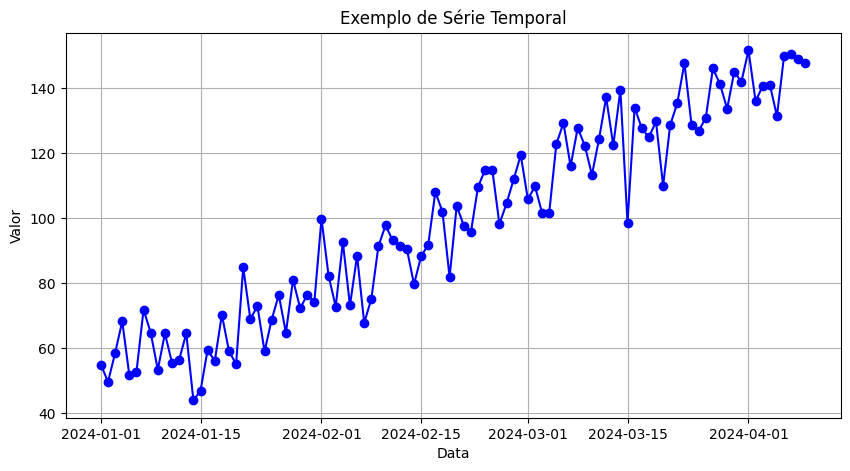

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Criando dados fictícios de uma série temporal
np.random.seed(42)
data = pd.date_range(start="2024-01-01", periods=100, freq='D')  # 100 dias
valores = np.linspace(50, 150, 100) + np.random.normal(scale=10, size=100)  # Tendência + ruído

# Criando um DataFrame
serie_temporal = pd.DataFrame({'Data': data, 'Valor': valores})

# Plotando a série temporal
plt.figure(figsize=(10,5))
plt.plot(serie_temporal['Data'], serie_temporal['Valor'], marker='o', linestyle='-', color='b')
plt.title("Exemplo de Série Temporal")
plt.xlabel("Data")
plt.ylabel("Valor")
plt.grid()
plt.show()

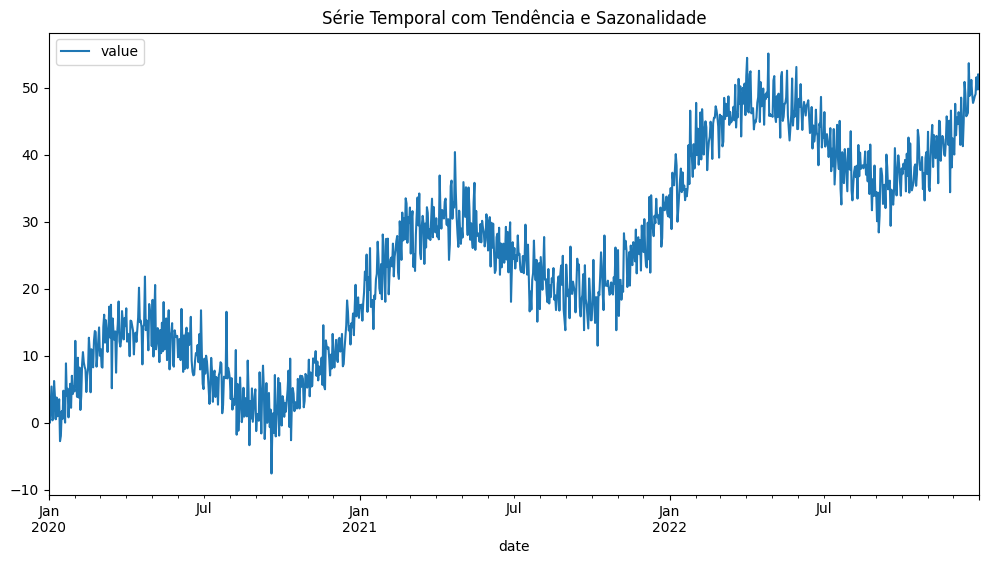

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Exemplo 1: Criando uma série temporal artificial
# Vamos criar dados com tendência, sazonalidade e ruído
np.random.seed(42)
dates = pd.date_range(start='2020-01-01', end='2022-12-31', freq='D')
trend = np.linspace(0, 50, len(dates))
seasonality = 10 * np.sin(2 * np.pi * dates.dayofyear / 365)
noise = np.random.normal(0, 3, len(dates))
data = trend + seasonality + noise

# Criando um DataFrame
ts = pd.DataFrame({'date': dates, 'value': data})
ts.set_index('date', inplace=True)

# Visualizando
ts.plot(figsize=(12, 6), title='Série Temporal com Tendência e Sazonalidade')
plt.show()

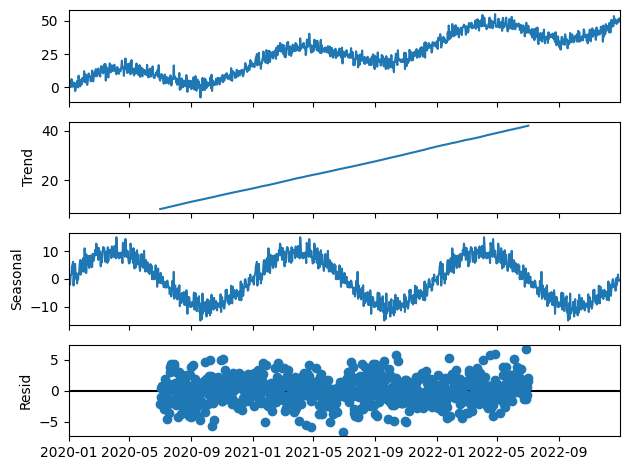

In [2]:
# Decompondo a série em seus componentes
result = seasonal_decompose(ts, model='additive', period=365)
result.plot()
plt.show()

In [3]:
# Testando estacionariedade
def test_stationarity(timeseries):
    # Dickey-Fuller test
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)

test_stationarity(ts['value'])

Test Statistic                   -0.492519
p-value                           0.893468
#Lags Used                       10.000000
Number of Observations Used    1085.000000
Critical Value (1%)              -3.436391
Critical Value (5%)              -2.864207
Critical Value (10%)             -2.568190
dtype: float64


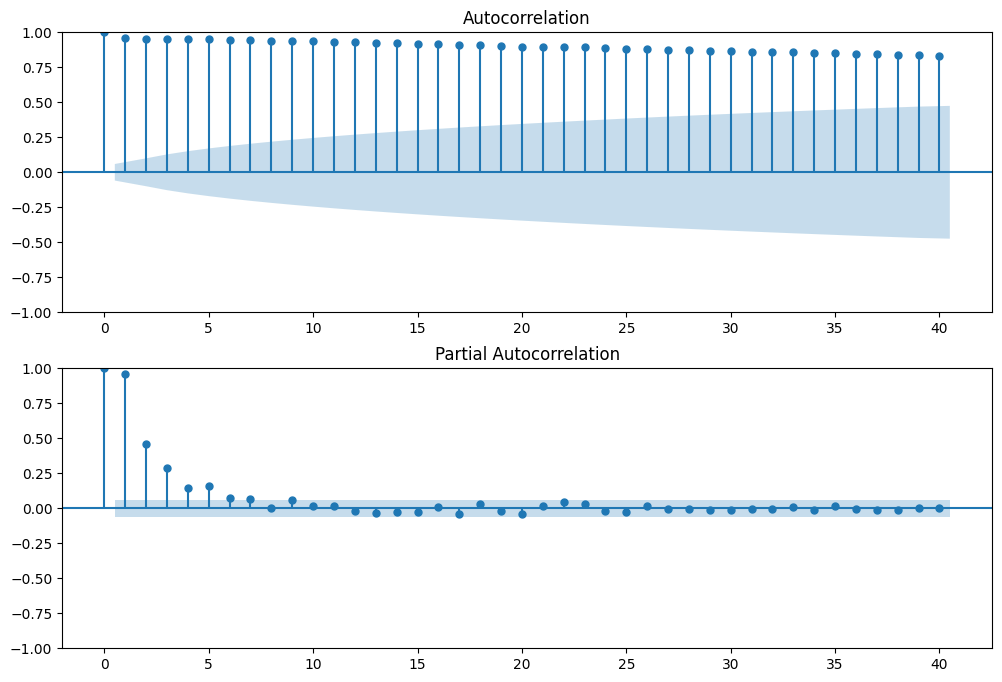

In [4]:
# Plotando funções de autocorrelação (ACF) e autocorrelação parcial (PACF)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(ts, lags=40, ax=ax1)
plot_pacf(ts, lags=40, ax=ax2)
plt.show()

C:\Users\Gustavo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Gustavo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Gustavo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                 1096
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -2808.929
Date:                Wed, 28 May 2025   AIC                           5623.858
Time:                        23:41:01   BIC                           5638.854
Sample:                    01-01-2020   HQIC                          5629.532
                         - 12-31-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0635      0.036     -1.769      0.077      -0.134       0.007
ma.L1         -0.8032      0.022    -36.014      0.000      -0.847      -0.759
sigma2         9.8902      0.427     23.185      0.0

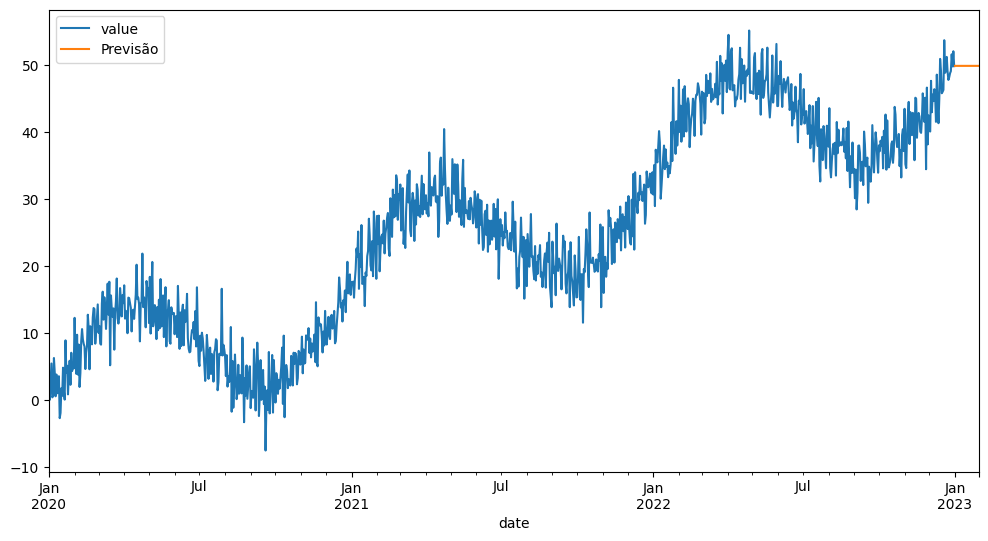

In [5]:
from statsmodels.tsa.arima.model import ARIMA

# Diferenciando para tornar a série estacionária
ts_diff = ts.diff().dropna()

# Ajustando modelo ARIMA
model = ARIMA(ts, order=(1,1,1))  # (p,d,q)
model_fit = model.fit()
print(model_fit.summary())

# Previsão
forecast = model_fit.forecast(steps=30)
ts.plot(figsize=(12,6))
forecast.plot(label='Previsão')
plt.legend()
plt.show()

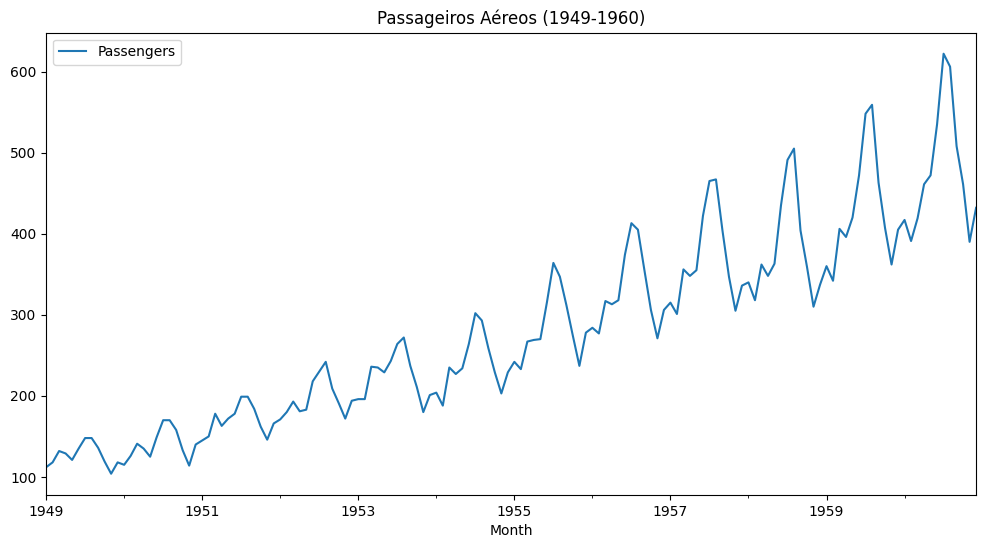

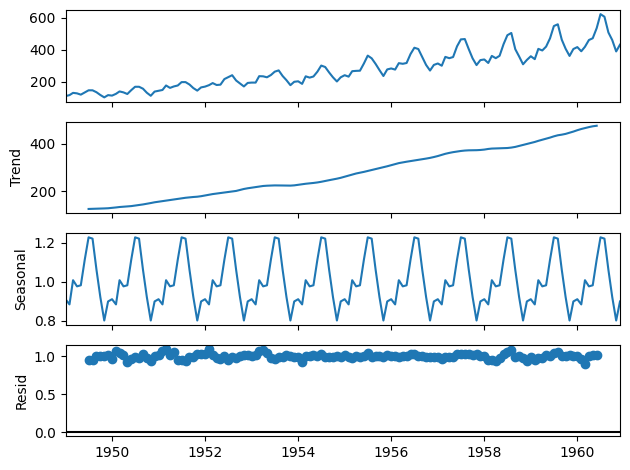

In [6]:
# Carregando dados famosos de passageiros de avião
airpass = pd.read_csv('https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv', 
                     parse_dates=['Month'], index_col='Month')
airpass.columns = ['Passengers']

# Visualizando
airpass.plot(figsize=(12,6), title='Passageiros Aéreos (1949-1960)')
plt.show()

# Decomposição
result_air = seasonal_decompose(airpass, model='multiplicative')
result_air.plot()
plt.show()